In [1]:
import os
from openai import OpenAI
client = OpenAI(api_key = os.getenv("OPENAI_API_KEY"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json
import io
import inspect
import requests
import ChatAPICallFunctionsLib as cfl
import AutoSTMFuctionsLib as stmfl

In [5]:
functions_dict_path = 'toolsjsdict.json'
with open(functions_dict_path, 'r') as file:
    toolsjsdict = json.load(file)


tools_list = [stmfl.load_txt_from_idl,stmfl.plot_topo,stmfl.polybackRow,stmfl.plot_fft,stmfl.fftamp]
files_to_load = ['06_10_24_002.txt','06_15_24_010.txt','06_16_24_006.txt']

In [6]:
image_pool = []
messages = [
        {"role": "system", "content": "The path to load data is %s, the fils to load under this path are %s" % ('Data', files_to_load)},
        {"role": "user", "content": 'load the txt file from given path and convert it into numpy array'}]

In [8]:
messages = [
        {"role": "system", "content": "The data arrays are: %s" % (image_pool)},
        {"role": "user", "content": 'please use the plot function to plot all the arrays as topography images'}]


In [9]:
messages = [
        {"role": "system", "content": "The data arrays are: %s" % (image_pool_polyback_2)},
        {"role": "user", "content": 'please use the plot function to plot all the arrays as topography images'}]

In [22]:
messages = [
        {"role": "system", "content": "The data arrays are: %s" % (image_pool_FFT_Amp)},
        {"role": "user", "content": 'please use the plot_fft function to plot all the arrays as Fourier transform images, with histgram range: hist = %s' %(['0','30'])}]

In [10]:
messages = [
        {"role": "system", "content": "The data arrays are: %s" % (image_pool)},
        {"role": "user", "content": 'please apply polybackRow function on all the arrays with polyord = %s' %('2')}]


In [12]:
messages = [
        {"role": "system", "content": "The data arrays are: %s" % (image_pool_polyback_2)},
        {"role": "user", "content": 'please apply fftamp function on all the arrays to get their Fourier transform'}]

Excuted function: [plot_fft] with arguments: {"data_name": "x06_10_24_002_polyback_2_FFT_Amp", "hist": ["0", "30"]}


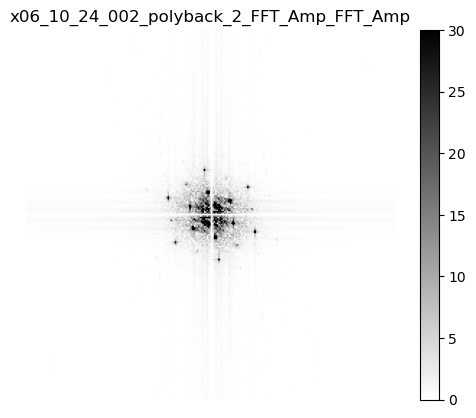

Excuted function: [plot_fft] with arguments: {"data_name": "x06_15_24_010_polyback_2_FFT_Amp", "hist": ["0", "30"]}


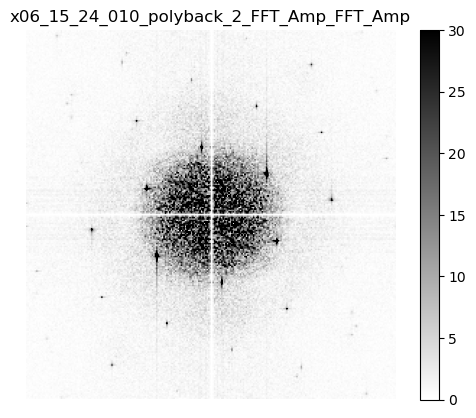

Excuted function: [plot_fft] with arguments: {"data_name": "x06_16_24_006_polyback_2_FFT_Amp", "hist": ["0", "30"]}


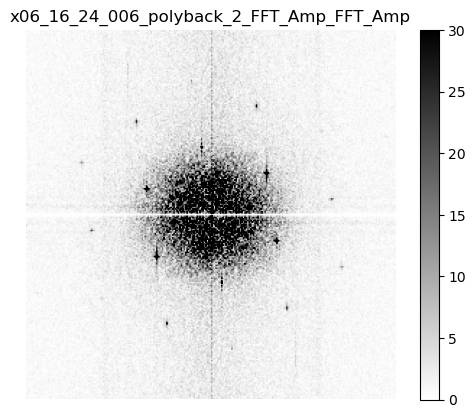

In [23]:
cfl.run_conversation1(messages = messages, tools_list = tools_list, toolsjsdict = toolsjsdict, global_namespace=globals())

In [ ]:
# model = 'gpt-4o'
# response = client.chat.completions.create(
#                 model="gpt-4o",
#                 messages=messages,
#                 tools=toolsjsdict,
#                 tool_choice="auto")
# response_message = response.choices[0].message.tool_calls
# print(response_message)

In [24]:
test_array = x06_15_24_010

In [25]:
# Compute the 2D Fourier transform
fourier_transform = np.fft.fft2(test_array)
fourier_transform_shifted = np.fft.fftshift(fourier_transform)
# Compute the magnitude spectrum
magnitude_spectrum = np.abs(fourier_transform_shifted)
# Compute the inverse 2D Fourier transform
inverse_fourier_transform = np.fft.ifft2(fourier_transform)


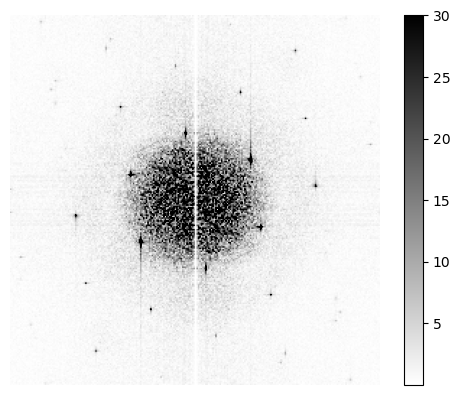

In [27]:

plt.imshow(magnitude_spectrum, cmap='gray_r',vmax = 30)
plt.colorbar()
plt.axis('off')
plt.show()
